Training on: cuda

Starting Training with StepLR Scheduler...
Epoch [1/12] | LR: 0.010000 | Loss: 0.1996
Epoch [2/12] | LR: 0.010000 | Loss: 0.1003
Epoch [3/12] | LR: 0.010000 | Loss: 0.0745
Epoch [4/12] | LR: 0.005000 | Loss: 0.0402
Epoch [5/12] | LR: 0.005000 | Loss: 0.0297
Epoch [6/12] | LR: 0.005000 | Loss: 0.0285
Epoch [7/12] | LR: 0.002500 | Loss: 0.0150
Epoch [8/12] | LR: 0.002500 | Loss: 0.0107
Epoch [9/12] | LR: 0.002500 | Loss: 0.0094
Epoch [10/12] | LR: 0.001250 | Loss: 0.0066
Epoch [11/12] | LR: 0.001250 | Loss: 0.0052
Epoch [12/12] | LR: 0.001250 | Loss: 0.0041


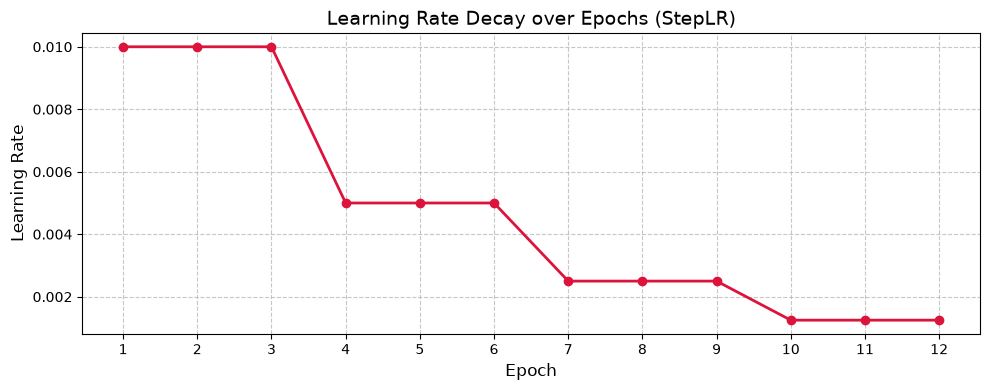

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Device & Data Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# 2. Model Definition (Flattened for 28x28 images)
def create_model():
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Linear(128, 10)
    ).to(device)

model = create_model()
criterion = nn.CrossEntropyLoss()

# 3. Optimizer and SCHEDULER setup
# We start with a relatively high learning rate (0.01)
optimizer = optim.Adam(model.parameters(), lr=0.01)

# StepLR: Decays the learning rate of each parameter group by gamma every step_size epochs
# Here, the LR will be multiplied by 0.5 every 3 epochs.
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

# 4. Training Loop
epochs = 12
lrs = []
train_losses = []

print("\nStarting Training with StepLR Scheduler...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    # Record the current learning rate before the epoch runs
    current_lr = scheduler.get_last_lr()[0]
    lrs.append(current_lr)
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step() # Updates the weights
        
        running_loss += loss.item()
        
    # --- CRITICAL STEP ---
    # The scheduler updates the learning rate AFTER the entire epoch is complete
    scheduler.step() 
    
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1}/{epochs}] | LR: {current_lr:.6f} | Loss: {avg_loss:.4f}")

# 5. Visualization: Plotting the Learning Rate Decay
plt.figure(figsize=(10, 4))
plt.plot(range(1, epochs + 1), lrs, marker='o', color='crimson', linewidth=2)
plt.title('Learning Rate Decay over Epochs (StepLR)', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, epochs + 1))
plt.tight_layout()
plt.show()